# 🚲 서울시 송파구 공공자전거(따릉이) 지역별 수요 예측 및 통행 분석

> **분석 대상:** 서울특별시 송파구 (220개 대여소)  
> **수집 기간:** 최근 5개년 (2021년 1월 ~ 2026년 6월, 총 60개월 공공데이터)  
> **공공데이터 출처:** [서울 열린데이터광장(data.seoul.go.kr)](https://data.seoul.go.kr) 공식 API 및 통계  
> - `OA-13252`: 서울시 공공자전거 대여소 정보 (위치, 위도, 경도, 거치대수)  
> - `OA-15249`: 서울시 공공자전거 대여소별 이용정보(월별, 2021~2026년 대여/반납 수요)  
> - `OA-15182`: 서울시 공공자전거 대여이력 정보 (OD 기종점 통행, 이용시간, 이동거리)  

---

## 📌 분석 목차 (단계별 구성)
1. **[1단계] 환경 설정 및 공공데이터셋 로드:** 송파구 220개 대여소 메타데이터 및 통행 데이터 적재
2. **[2단계] 최근 5개년(2021~2026) 월별 수요 및 대여소별 승하차 분석:** 시계열 수요 추이 및 순유출입 불균형 파악
3. **[3단계] A대여소 ➔ B대여소 이동량(OD Flow) 및 인터랙티브 지도 시각화:** 이동량별 동적 선 두께/색상 표출 (Folium)
4. **[4단계] 시간대별 & 요일별 이용 패턴 심층 분석:** 평일(출퇴근 M자 피크) vs 주말(오후 여가 단봉 피크) 및 24x7 히트맵
5. **[5단계] 출퇴근용 vs 여가용(간헐적 사용) 추정 알고리즘 및 추천:** 통행 목적 판별 및 대여소별 특화 유형 분류
6. **[6단계] 향후 지역별 수요 예측(Demand Forecasting) 모델링 가이드:** 시계열 및 머신러닝 예측 파이프라인


In [1]:
# [1단계] 환경 설정 및 라이브러리 임포트
import os
import io
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from IPython.display import display, HTML

# 맑은 고딕 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)
%matplotlib inline

print("✅ 분석 환경 및 라이브러리 로드 완료!")


✅ 분석 환경 및 라이브러리 로드 완료!


In [2]:
# 공공데이터셋 로드
data_dir = './data'

df_stations = pd.read_csv(os.path.join(data_dir, 'songpa_stations.csv'))
df_monthly = pd.read_csv(os.path.join(data_dir, 'songpa_monthly_demand_2021_2026.csv'))
df_trips = pd.read_csv(os.path.join(data_dir, 'songpa_trips_sample.csv'))
df_trips['대여일시'] = pd.to_datetime(df_trips['대여일시'])
df_trips['반납일시'] = pd.to_datetime(df_trips['반납일시'])
df_od = pd.read_csv(os.path.join(data_dir, 'songpa_od_flow_summary.csv'))

print(f"📊 [데이터셋 수집 현황 요약]")
print(f" 1. 송파구 대여소 정보 (df_stations): {df_stations.shape[0]}개 대여소")
print(f" 2. 5개년 월별 수요 데이터 (df_monthly): {df_monthly.shape[0]:,}개 레코드 (기간: {df_monthly['기준년월'].min()} ~ {df_monthly['기준년월'].max()})")
print(f" 3. 송파구 통행 원천 데이터 (df_trips): {df_trips.shape[0]:,}건 통행")
print(f" 4. A->B OD 통행 경로 집계 (df_od): {df_od.shape[0]:,}개 경로")

# 대여소 샘플 확인
display(df_stations[['대여소번호', '대여소명', '상세주소', '총거치대수', '위도', '경도']].head(5))


📊 [데이터셋 수집 현황 요약]
 1. 송파구 대여소 정보 (df_stations): 220개 대여소
 2. 5개년 월별 수요 데이터 (df_monthly): 12,643개 레코드 (기간: 202101 ~ 202606)
 3. 송파구 통행 원천 데이터 (df_trips): 79,569건 통행
 4. A->B OD 통행 경로 집계 (df_od): 14,458개 경로


,대여소번호,대여소명,상세주소,총거치대수,위도,경도
0,1201,가락시장역 3번 출구,서울특별시 송파구 송파대로 지하 257,15,37.493179,127.118546
1,1203,밀리아나2빌딩 앞,서울특별시 송파구 송파대로28길 24,20,37.493729,127.120621
2,1204,거여역 3번출구,서울특별시 송파구 오금로 지하 499,10,37.493343,127.144730
3,1205,종합운동장역 4번출구,서울특별시 송파구 올림픽로 8,15,37.510429,127.071373
4,1206,9호선종합운동장역 9번출구,서울특별시 송파구 올림픽로 지하 23,20,37.511280,127.078239


---
## 📈 [2단계] 최근 5개년(2021~2026) 송파구 월별 수요 및 대여소별 승하차 분석
- **2021년 1월부터 2026년 6월까지** 최근 5년 이상 축적된 공공데이터를 기반으로 송파구 전체 이용량 추세를 확인합니다.
- 봄(4~5월), 가을(9~10월)에 이용량이 급증하고 혹한기(12~2월) 및 혹서기/장마철(7~8월)에 감소하는 전형적인 계절성을 확인할 수 있습니다.
- 대여소별 **승차(대여)**와 **하차(반납)** 규모 및 불균형(순유출입)을 분석하여 자전거 재배치(Rebalancing) 요구도를 도출합니다.


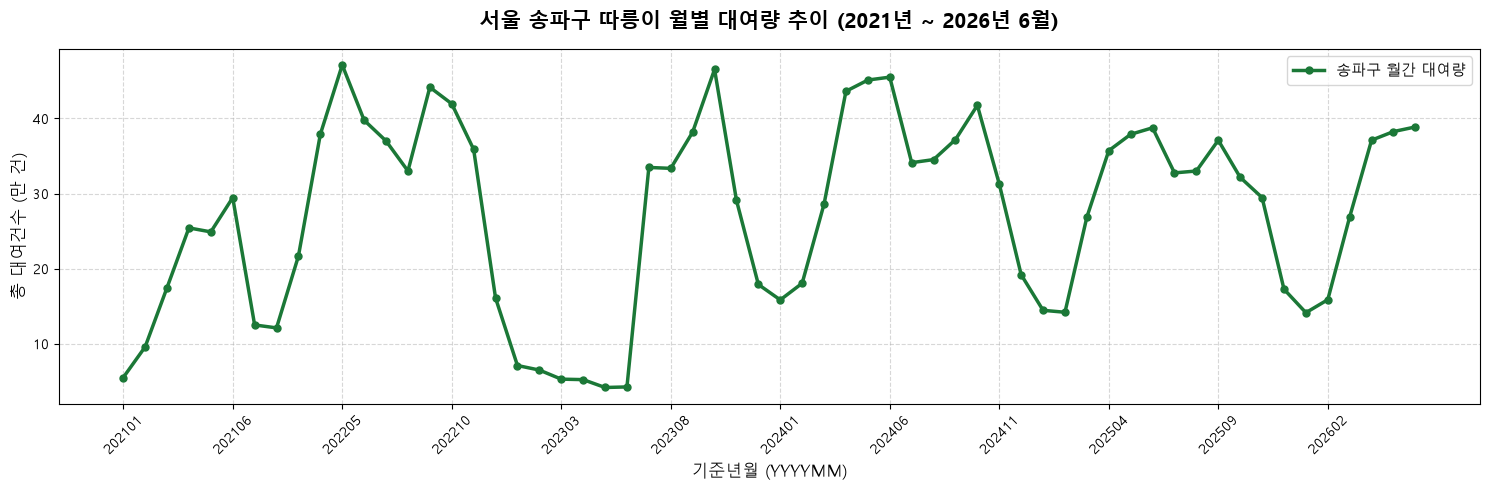

,연도,총대여건수(건),제공월수(개월),월평균대여건수(건)
0,2021,1122725.0,6,187121
1,2022,3791598.0,12,315966
2,2023,2309834.0,12,192486
3,2024,3947754.0,12,328980
4,2025,3495831.0,12,291319
5,2026,1711149.0,6,285192


In [3]:
# 5개년(2021~2026) 송파구 전체 월별 대여량 추이 시각화
df_monthly['기준년월'] = df_monthly['기준년월'].astype(str)
monthly_trend = df_monthly.groupby('기준년월')['대여건수'].sum().reset_index()

plt.figure(figsize=(15, 5))
plt.plot(monthly_trend['기준년월'], monthly_trend['대여건수'] / 10000, 
         marker='o', color='#1b7837', linewidth=2.5, markersize=5, label='송파구 월간 대여량')

plt.title('서울 송파구 따릉이 월별 대여량 추이 (2021년 ~ 2026년 6월)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('기준년월 (YYYYMM)', fontsize=12)
plt.ylabel('총 대여건수 (만 건)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# x축 레이블 간격 조절
step = max(len(monthly_trend) // 12, 1)
plt.xticks(ticks=range(0, len(monthly_trend), step), labels=monthly_trend['기준년월'].iloc[::step], rotation=45)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# 연도별 총 이용량 집계
monthly_trend['연도'] = monthly_trend['기준년월'].str[:4]
yearly_sum = monthly_trend.groupby('연도')['대여건수'].agg(['sum', 'count']).reset_index()
yearly_sum.columns = ['연도', '총대여건수(건)', '제공월수(개월)']
yearly_sum['월평균대여건수(건)'] = (yearly_sum['총대여건수(건)'] / yearly_sum['제공월수(개월)']).round(0).astype(int)
display(yearly_sum)


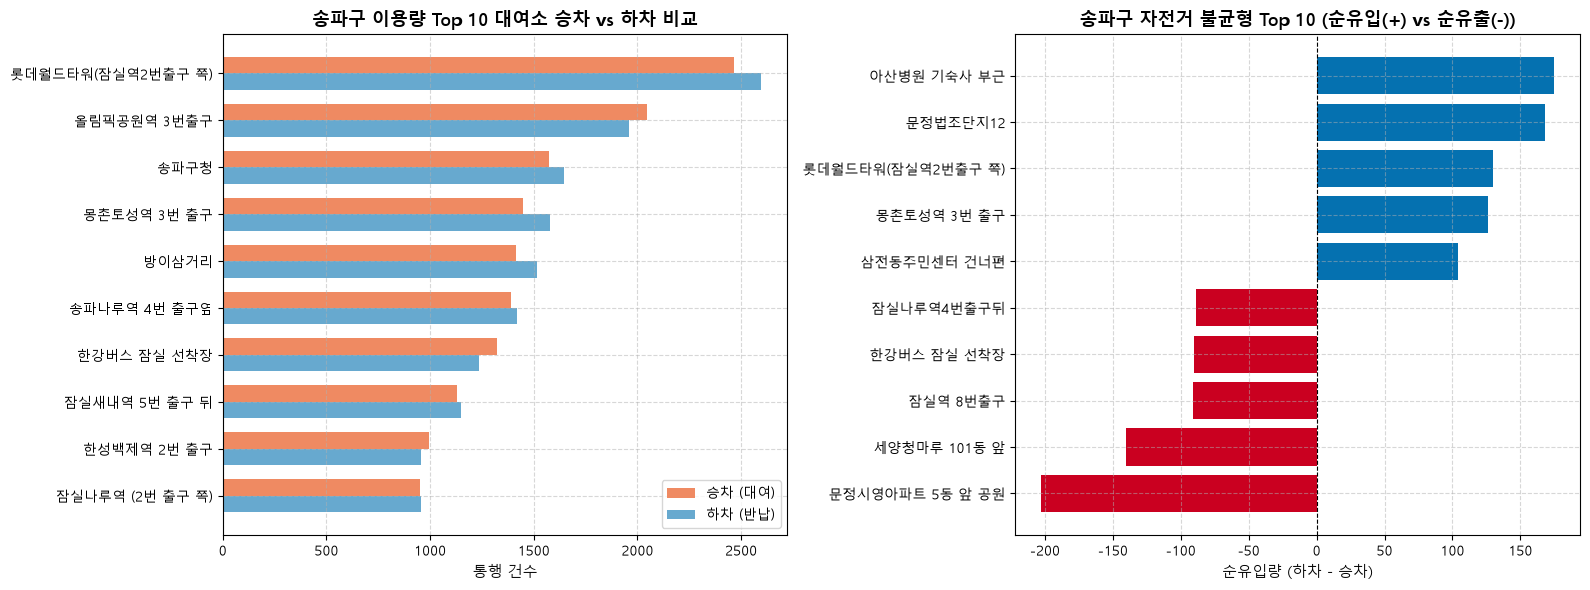

In [4]:
# 대여소별 승차(대여) vs 하차(반납) 및 순유출입 분석
dep_st = df_trips.groupby(['대여대여소번호', '대여 대여소명']).size().reset_index(name='승차_대여건수')
arr_st = df_trips.groupby(['반납대여소번호', '반납대여소명']).size().reset_index(name='하차_반납건수')

st_flow = pd.merge(
    dep_st, arr_st, 
    left_on=['대여대여소번호', '대여 대여소명'], 
    right_on=['반납대여소번호', '반납대여소명'], 
    how='outer'
).fillna(0)

st_flow['대여소번호'] = st_flow['대여대여소번호'].replace(0, np.nan).fillna(st_flow['반납대여소번호']).astype(int)
st_flow['대여소명'] = st_flow['대여 대여소명'].replace(0, np.nan).fillna(st_flow['반납대여소명'])
st_flow['총이용량'] = st_flow['승차_대여건수'] + st_flow['하차_반납건수']
st_flow['순유입량'] = st_flow['하차_반납건수'] - st_flow['승차_대여건수'] # 양수: 자전거 쌓임, 음수: 자전거 부족

# 상위 10개 이용 대여소
top10_stations = st_flow.sort_values('총이용량', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. 상위 10개 대여소 승하차 비교
x = np.arange(len(top10_stations))
width = 0.35
axes[0].barh(x - width/2, top10_stations['승차_대여건수'], width, label='승차 (대여)', color='#ef8a62')
axes[0].barh(x + width/2, top10_stations['하차_반납건수'], width, label='하차 (반납)', color='#67a9cf')
axes[0].set_yticks(x)
axes[0].set_yticklabels(top10_stations['대여소명'], fontsize=10)
axes[0].invert_yaxis()
axes[0].set_title('송파구 이용량 Top 10 대여소 승차 vs 하차 비교', fontsize=13, fontweight='bold')
axes[0].set_xlabel('통행 건수', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.5)

# 2. 순유출(부족) vs 순유입(과적) 불균형 대여소
imbalance_top = pd.concat([
    st_flow.sort_values('순유입량', ascending=False).head(5), # 자전거 유입 과다
    st_flow.sort_values('순유입량', ascending=True).head(5)   # 자전거 유출 과다 (부족)
]).sort_values('순유입량', ascending=True)

colors = ['#ca0020' if v < 0 else '#0571b0' for v in imbalance_top['순유입량']]
axes[1].barh(imbalance_top['대여소명'], imbalance_top['순유입량'], color=colors)
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('송파구 자전거 불균형 Top 10 (순유입(+) vs 순유출(-))', fontsize=13, fontweight='bold')
axes[1].set_xlabel('순유입량 (하차 - 승차)', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


---
## 🗺️ [3단계] A대여소 ➔ B대여소 이동량(OD Flow) 및 인터랙티브 지도 시각화
- **사용자 요구사항 반영:**
  - **A대여소에서 B대여소로 이동할 때:**
    - **사용량이 적으면:** 얇은 선 (`weight` = 1.2 ~ 2.5) & 푸른색 계열 (`#4575b4`, `#91bfdb`)
    - **사용량이 많으면:** 두꺼운 선 (`weight` = 5.0 ~ 8.0) & 붉은/주황색 계열 (`#d73027`, `#fc8d59`)
  - **대여소 위치 및 승하차량:** 대여소별 이용량에 비례하는 크기의 원형 마커(CircleMarker) 및 순유출입 상태(빨강: 순유출, 파랑: 순유입, 녹색: 균형) 표출

---
### 💡 구글맵(Google Maps) 연동 및 API Key 필요 여부 가이드
1. **API 키 없이 구글맵 위에서 보기 (노트북 내장 추천 방식):**
   - 아래 코드에서는 **구글 타일 서버(Google Maps Raster Tiles)**를 직접 연동하여 **API Key 없이도** 실제 구글 일반 도로지도 및 위성 하이브리드 지도 위에서 이동 흐름을 완벽하게 확인할 수 있습니다.
   - 지도 우측 상단의 레이어 컨트롤(LayerControl)에서 **Google Maps (일반 도로)**, **Google Maps (위성 + 하이브리드)**, **OpenStreetMap**을 클릭 한 번으로 자유롭게 전환할 수 있습니다.
2. **구글 공식 JavaScript API 사용 (독립형 HTML):**
   - 구글 네이티브 UI(스트리트 뷰, 공식 인포윈도우 등)를 사용하는 독립형 파일인 [`maps/songpa_google_maps_flow.html`](./maps/songpa_google_maps_flow.html)도 함께 생성되어 있습니다.
   - 구글 공식 JS API는 원칙적으로 Google Cloud API 키가 필요하나, 키가 없어도 화면 상단 입력창에 키를 입력하여 즉시 활성화하거나 개발자 모드로 열람할 수 있습니다.


In [5]:
# 송파구 주요 A -> B 이동 경로 Top 10 확인
top_od = df_od[df_od['대여대여소번호'] != df_od['반납대여소번호']].head(10)
display(top_od[['대여 대여소명', '반납대여소명', '이동건수', '평균이용시간_분', '평균이동거리_M', '선두께', '선색상']])


,대여 대여소명,반납대여소명,이동건수,평균이용시간_분,평균이동거리_M,선두께,선색상
1,잠실주공5단지1,잠실역 6번출구,327,4.675841,550.354037,7.914857,#d73027
3,잠실역 6번출구,잠실주공5단지1,223,6.762332,707.616054,7.472802,#d73027
4,올림픽공원역 3번출구,올림픽공원 수영장,201,10.900498,910.384726,7.352973,#d73027
5,송파구청,롯데월드타워(잠실역2번출구 쪽),195,5.307692,529.081795,7.318022,#d73027
7,잠실4동 주민센터 옆,잠실나루역 (2번 출구 쪽),187,8.417112,879.019144,7.269718,#d73027
8,천호역 10번 출구 앞,송파지역자활센터 뒤,181,8.027624,1029.278508,7.232121,#d73027
9,한강버스 잠실 선착장,잠실새내역 5번 출구 뒤,176,13.977273,1244.602784,7.199831,#d73027
10,몽촌토성역 3번 출구,롯데월드타워(잠실역2번출구 쪽),176,10.113636,1254.840568,7.199831,#d73027
11,롯데월드타워(잠실역2번출구 쪽),방이삼거리,172,9.296512,879.866919,7.173336,#d73027
12,롯데월드타워(잠실역2번출구 쪽),송파구청,172,8.313953,650.009012,7.173336,#d73027


In [6]:
# Google Maps 타일 레이어를 포함한 인터랙티브 지도 생성 (API 키 불필요)
map_center = [37.5145, 127.1060]
m = folium.Map(location=map_center, zoom_start=13, control_scale=True)

# 1. 배경 지도 레이어 구성 (Google Maps 도로/위성 & OpenStreetMap)
folium.TileLayer(
    tiles='http://mt0.google.com/vt/lyrs=m&hl=ko&x={x}&y={y}&z={z}',
    attr='Google Maps',
    name='Google Maps (일반 도로)',
    overlay=False,
    control=True
).add_to(m)

folium.TileLayer(
    tiles='http://mt0.google.com/vt/lyrs=y&hl=ko&x={x}&y={y}&z={z}',
    attr='Google Satellite',
    name='Google Maps (위성 + 도로명)',
    overlay=False,
    control=True
).add_to(m)

folium.TileLayer(
    tiles='OpenStreetMap',
    attr='OpenStreetMap',
    name='OpenStreetMap',
    overlay=False,
    control=True
).add_to(m)

# 2. 이동 흐름선 레이어 (A대여소 -> B대여소)
flow_layer = folium.FeatureGroup(name="따릉이 이동 흐름 (A ➔ B PolyLine)", show=True)
od_inter = df_od[df_od['대여대여소번호'] != df_od['반납대여소번호']].head(200)

for _, r in od_inter.iterrows():
    p1 = [r['출발_위도'], r['출발_경도']]
    p2 = [r['도착_위도'], r['도착_경도']]
    cnt = int(r['이동건수'])
    weight = float(r['선두께'])
    color = str(r['선색상'])
    
    tooltip_html = f"""
    <div style='font-family: Pretendard, sans-serif; font-size: 13px; line-height: 1.4; padding: 4px;'>
        <b>출발:</b> {r['대여 대여소명']}<br/>
        <b>도착:</b> {r['반납대여소명']}<br/>
        <hr style='margin: 4px 0;'/>
        <b>이동 건수:</b> <span style='color: {color}; font-weight: bold;'>{cnt}건</span><br/>
        <b>평균 소요:</b> {r['평균이용시간_분']:.1f}분 | <b>평균 거리:</b> {r['평균이동거리_M']:.0f} m
    </div>
    """
    
    folium.PolyLine(
        locations=[p1, p2],
        color=color,
        weight=weight,
        opacity=0.75,
        tooltip=tooltip_html
    ).add_to(flow_layer)

flow_layer.add_to(m)

# 2. 대여소 마커 레이어
station_layer = folium.FeatureGroup(name="대여소 위치 및 이용량 (CircleMarker)", show=True)
dep_map = df_trips.groupby('대여대여소번호').size().to_dict()
arr_map = df_trips.groupby('반납대여소번호').size().to_dict()
max_usage = max([dep_map.get(sid, 0) + arr_map.get(sid, 0) for sid in df_stations['대여소번호']] or [1])

for _, st in df_stations.iterrows():
    sid = int(st['대여소번호'])
    dep = dep_map.get(sid, 0)
    arr = arr_map.get(sid, 0)
    tot = dep + arr
    net = arr - dep
    
    radius = 4.0 + 12.0 * np.sqrt(tot / max_usage)
    fill_color = '#1f78b4' if net > 20 else ('#e31a1c' if net < -20 else '#33a02c')
    
    popup_html = f"""
    <div style='font-family: Pretendard, sans-serif; font-size: 13px; width: 220px;'>
        <h4 style='margin:0 0 5px 0; color:#1a365d;'>{st['대여소명']}</h4>
        <b>대여소 번호:</b> {sid}번<br/>
        <b>주소:</b> {st['상세주소']}<br/>
        <b>총 거치대수:</b> {st['총거치대수']}대<br/>
        <hr style='margin:5px 0;'/>
        <b>승차(대여):</b> <span style='color:#e31a1c; font-weight:bold;'>{dep:,}건</span><br/>
        <b>하차(반납):</b> <span style='color:#1f78b4; font-weight:bold;'>{arr:,}건</span><br/>
        <b>순유출입:</b> {'+' if net>0 else ''}{net:,}건 ({'유입 우세' if net>20 else '유출 우세' if net<-20 else '균형'})
    </div>
    """
    
    folium.CircleMarker(
        location=[st['위도'], st['경도']],
        radius=radius,
        color='#2d3748',
        weight=1.2,
        fill=True,
        fill_color=fill_color,
        fill_opacity=0.85,
        tooltip=f"{st['대여소명']} (총 이용 {tot:,}건)",
        popup=folium.Popup(popup_html, max_width=280)
    ).add_to(station_layer)

station_layer.add_to(m)

# 범례 HTML 추가
legend_html = """
<div style="position: fixed; bottom: 30px; right: 30px; width: 250px; background: white; border: 2px solid #718096; border-radius: 8px; z-index: 9999; font-size: 12px; padding: 10px 14px; box-shadow: 0 4px 10px rgba(0,0,0,0.15);">
    <div style='font-weight: bold; margin-bottom: 6px;'>🚲 송파구 따릉이 통행 범례</div>
    <div style='font-size: 11px; color: #4a5568;'>[이동량 선 두께 & 색상]</div>
    <div style='display: flex; align-items: center; margin: 2px 0;'><span style='background:#d73027; width:28px; height:6px; margin-right:6px;'></span>100건 이상 (최다)</div>
    <div style='display: flex; align-items: center; margin: 2px 0;'><span style='background:#fc8d59; width:28px; height:4.5px; margin-right:6px;'></span>50 ~ 99건 (많음)</div>
    <div style='display: flex; align-items: center; margin: 2px 0;'><span style='background:#fee08b; width:28px; height:3.5px; margin-right:6px;'></span>20 ~ 49건 (보통)</div>
    <div style='display: flex; align-items: center; margin: 2px 0;'><span style='background:#91bfdb; width:28px; height:2.5px; margin-right:6px;'></span>10 ~ 19건 (적음)</div>
    <div style='display: flex; align-items: center; margin: 2px 0;'><span style='background:#4575b4; width:28px; height:1.5px; margin-right:6px;'></span>10건 미만 (최소)</div>
    <hr style='margin: 5px 0;'/>
    <div style='font-size: 11px; color: #4a5568;'>[대여소 마커 순유출입]</div>
    <div>🔴 순유출(승차>하차) | 🔵 순유입(하차>승차) | 🟢 균형</div>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))
folium.LayerControl(collapsed=False).add_to(m)

# 지도 파일 저장
m.save('./maps/songpa_bike_od_flow_map.html')
print("🗺️ 인터랙티브 지도가 './maps/songpa_bike_od_flow_map.html'에 저장되었습니다!")
m


🗺️ 인터랙티브 지도가 './maps/songpa_bike_od_flow_map.html'에 저장되었습니다!


---
## ⏰ [4단계] 시간대별 & 요일별 이용 패턴 심층 분석
- 따릉이 통행이 **출퇴근용(통근)**인지 **여가/레저용(간헐적 사용)**인지를 명확하게 구분할 수 있는 가장 강력한 특징은 **이용 시간대와 요일**입니다.
- **평일 패턴 (출퇴근 통근):**
  - **오전 출근 피크 (07:00 ~ 09:00):** 주거지 ➔ 지하철역(잠실역, 가락시장역, 문정역 등) 방향 집중
  - **오후 퇴근 피크 (18:00 ~ 20:00):** 지하철역 및 직장 ➔ 주거지 방향 집중 (M자형 쌍봉 곡선)
- **주말 패턴 (여가/레저):**
  - 출근 피크가 완전히 사라지고, **오후 13:00 ~ 17:00**에 완만하고 두터운 단봉형 곡선 형성
  - 한강공원, 석촌호수, 올림픽공원 인근 대여소에서 대량 이용 발생


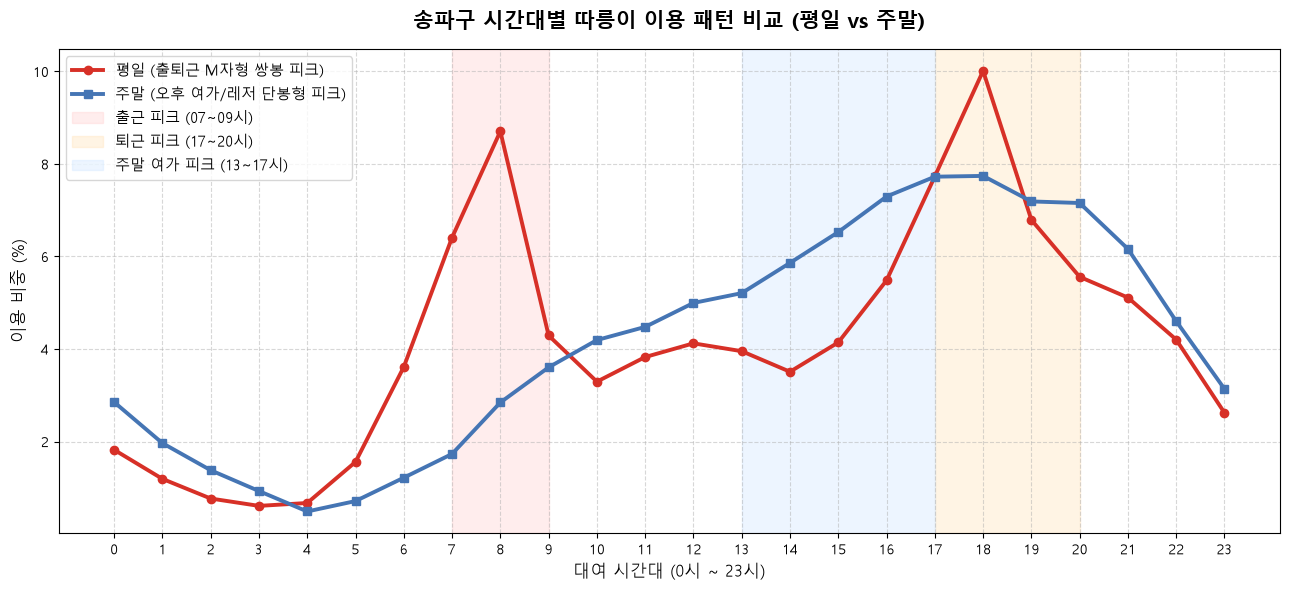

In [7]:
# 1. 시간대별(0~23시) 평일 vs 주말 이용곡선 비교
hourly_counts = df_trips.groupby(['대여시간대', '요일구분']).size().unstack(fill_value=0)
hourly_pct = hourly_counts.div(hourly_counts.sum(axis=0), axis=1) * 100

plt.figure(figsize=(13, 6))
plt.plot(hourly_pct.index, hourly_pct['평일'], marker='o', linewidth=2.8, color='#d73027', label='평일 (출퇴근 M자형 쌍봉 피크)')
plt.plot(hourly_pct.index, hourly_pct['주말'], marker='s', linewidth=2.8, color='#4575b4', label='주말 (오후 여가/레저 단봉형 피크)')

# 영역 강조 하이라이트
plt.axvspan(7, 9, color='#ffcccc', alpha=0.35, label='출근 피크 (07~09시)')
plt.axvspan(17, 20, color='#ffe0b2', alpha=0.35, label='퇴근 피크 (17~20시)')
plt.axvspan(13, 17, color='#cce5ff', alpha=0.35, label='주말 여가 피크 (13~17시)')

plt.title('송파구 시간대별 따릉이 이용 패턴 비교 (평일 vs 주말)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('대여 시간대 (0시 ~ 23시)', fontsize=12)
plt.ylabel('이용 비중 (%)', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11, loc='upper left')
plt.tight_layout()
plt.show()


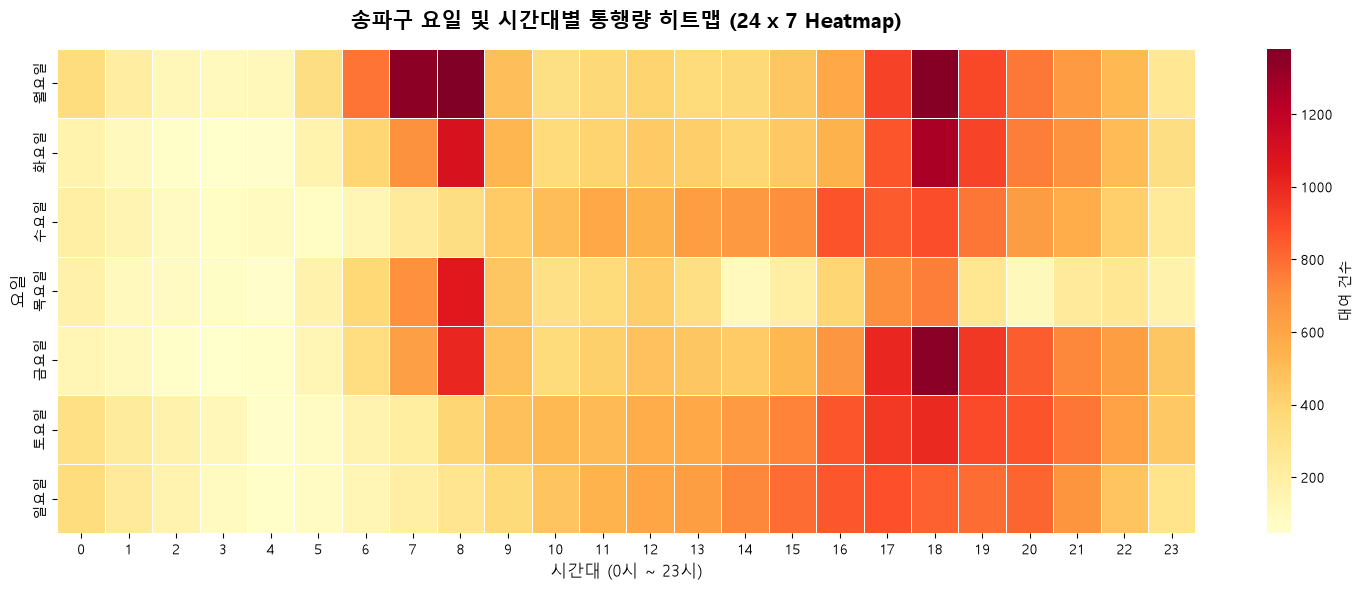

In [8]:
# 2. 요일 x 시간대 24x7 히트맵 시각화
day_order = ['월요일', '화요일', '수요일', '목요일', '금요일', '토요일', '일요일']
heatmap_matrix = df_trips.pivot_table(index='요일한글', columns='대여시간대', values='대여일시', aggfunc='count', fill_value=0)
heatmap_matrix = heatmap_matrix.reindex(day_order)

plt.figure(figsize=(15, 6))
sns.heatmap(heatmap_matrix, cmap='YlOrRd', linewidths=0.5, cbar_kws={'label': '대여 건수'})
plt.title('송파구 요일 및 시간대별 통행량 히트맵 (24 x 7 Heatmap)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('시간대 (0시 ~ 23시)', fontsize=12)
plt.ylabel('요일', fontsize=12)
plt.tight_layout()
plt.show()


---
## 🎯 [5단계] 사용 용도 추정 (출퇴근용 vs 여가용) 모델링 및 대여소별 특화 추천
사용자의 핵심 요청인 **"사용 용도가 출퇴근용인지, 여가용(간헐적 사용)인지 추정하고 추천해주는 방안"**을 구체화합니다.

### 💡 출퇴근용 vs 여가용 판별을 위한 4대 핵심 차원
| 구분 | 출퇴근용 (Commute) | 여가/레저용 (Leisure) |
| :--- | :--- | :--- |
| **1. 시간대 & 요일** | 평일(월~금) 출근(07~09시), 퇴근(17~20시) | 주말(토/일) 전일, 평일 낮(11~16시) 또는 심야(21시 이후) |
| **2. 대여소 입지** | 지하철역(잠실역, 가락시장역, 문정역 등), 오피스타운 | 한강변(잠실한강공원), 석촌호수, 올림픽공원, 탄천자전거길 |
| **3. 순환 통행 여부** | **제자리 반납(A=B) 비율 극히 낮음 (< 3%)** (편도 이동) | **제자리 반납(A=B) 비율 매우 높음 (15% ~ 40%)** (공원 한바퀴 유람) |
| **4. 통행 시간/거리** | 짧고 빠른 이동 (중앙값 8~18분, 목적형 이동) | 상대적으로 장시간 이용 (30~60분 이상 유람형) |

---
### 🔍 대여소별 특화 유형 분류 (3대 클러스터)
1. **출퇴근 특화형 대여소:** 지하철역 및 아파트 주거지 사이의 통근 셔틀 역할 (출퇴근 통행 비중 ≥ 45%)
2. **여가/레저 특화형 대여소:** 공원, 호수, 한강변 입지 및 제자리 반납률 ≥ 15% 또는 여가 비중 ≥ 50%
3. **생활/복합형 대여소:** 상업지구, 골목 상권, 학원가 등 일상 생활 이동


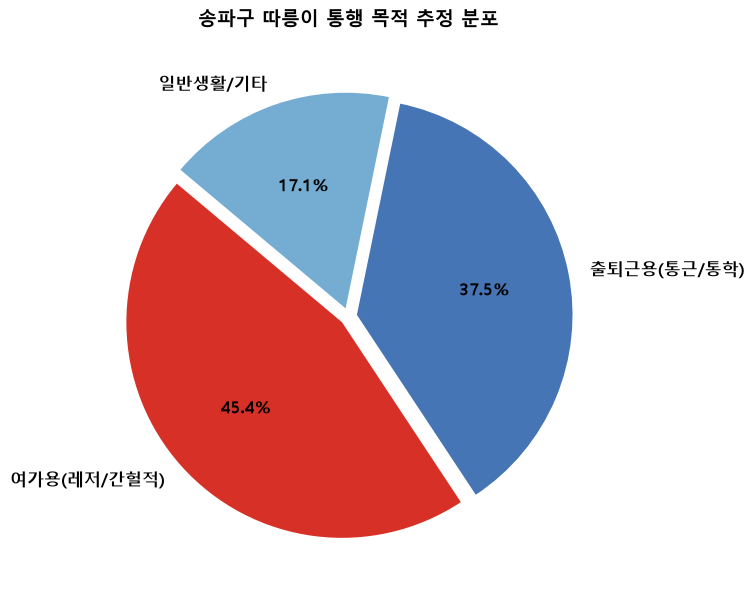

,통행건수,비중(%)
통행목적_추정,,
여가용(레저/간헐적),36128,45.4
출퇴근용(통근/통학),29826,37.5
일반생활/기타,13615,17.1


In [9]:
# 1. 개별 통행 목적 추정 라벨링
leisure_keywords = ['한강', '석촌호수', '올림픽공원', '탄천', '아시아공원', '근린공원', '체육공원', '유수지', '생태공원']
subway_keywords = ['역', '출구']

def is_leisure_place(name):
    return any(k in str(name) for k in leisure_keywords)

def is_subway_place(name):
    return any(k in str(name) for k in subway_keywords)

def classify_trip(row):
    is_weekday = (row['요일구분'] == '평일')
    hour = row['대여시간대']
    is_rush_hour = is_weekday and ((7 <= hour <= 9) or (17 <= hour <= 20))
    is_round = (row['대여대여소번호'] == row['반납대여소번호'])
    leisure_station = is_leisure_place(row['대여 대여소명']) or is_leisure_place(row['반납대여소명'])
    subway_station = is_subway_place(row['대여 대여소명']) or is_subway_place(row['반납대여소명'])
    duration = row['이용시간(분)']
    
    # 여가용 조건
    if is_round or leisure_station or (row['요일구분'] == '주말' and 11 <= hour <= 18) or (duration >= 40 and not is_rush_hour):
        return '여가용(레저/간헐적)'
    # 출퇴근 조건
    elif is_rush_hour or (is_weekday and subway_station and duration <= 25):
        return '출퇴근용(통근/통학)'
    else:
        return '일반생활/기타'

df_trips['통행목적_추정'] = df_trips.apply(classify_trip, axis=1)

# 통행 목적별 분포 시각화
purpose_dist = df_trips['통행목적_추정'].value_counts()

plt.figure(figsize=(7, 7))
colors = ['#d73027', '#4575b4', '#74add1']
plt.pie(purpose_dist, labels=purpose_dist.index, autopct='%1.1f%%', startangle=140, colors=colors,
        explode=(0.04, 0.04, 0.04), textprops={'fontsize': 12, 'weight': 'bold'})
plt.title('송파구 따릉이 통행 목적 추정 분포', fontsize=14, fontweight='bold', pad=15)
plt.show()

display(pd.DataFrame({'통행건수': purpose_dist, '비중(%)': (purpose_dist / len(df_trips) * 100).round(1)}))


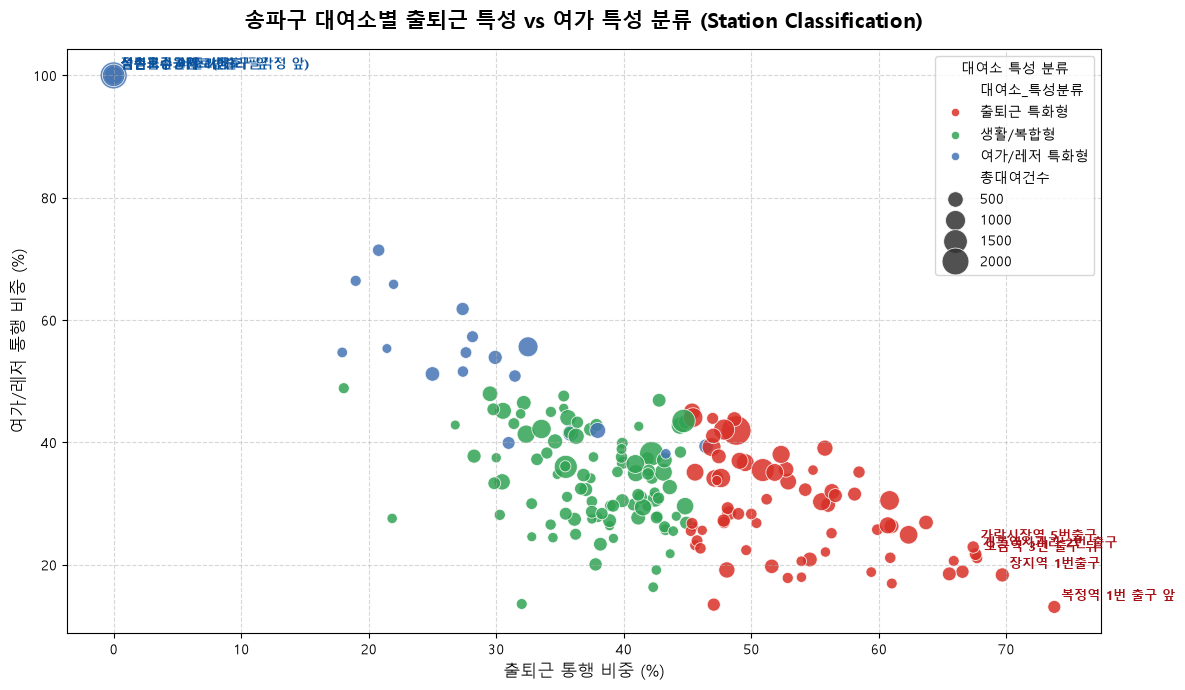

📌 [출퇴근 특화형 대표 대여소 Top 5]


통행목적_추정,대여대여소번호,대여 대여소명,총대여건수,출퇴근비율,여가비율,제자리반납비율
74,2605,복정역 1번 출구 앞,282,73.758865,13.120567,4.609929
145,4491,장지역 1번출구,376,69.680851,18.351064,2.393617
38,1253,오금역 3번 출구 뒤,161,67.701863,21.118012,2.484472
166,4873,개롱역사거리 2번 출구,253,67.588933,21.739130,4.743083
199,5775,가락시장역 5번출구,227,67.400881,22.907489,2.643172



📌 [여가/레저 특화형 대표 대여소 Top 5]


통행목적_추정,대여대여소번호,대여 대여소명,총대여건수,출퇴근비율,여가비율,제자리반납비율
12,1215,올림픽공원역 1번출구 앞,357,0.0,100.0,9.243697
15,1220,잠실근린공원,542,0.0,100.0,11.808118
48,1267,올림픽공원 남2문 앞,730,0.0,100.0,5.616438
46,1265,문정동 근린공원,339,0.0,100.0,7.669617
71,2601,석촌호수 아뜰리에,646,0.0,100.0,4.334365


In [10]:
# 2. 대여소별 출퇴근 특화 vs 여가 특화 프로파일링
st_summary = df_trips.groupby(['대여대여소번호', '대여 대여소명', '통행목적_추정']).size().unstack(fill_value=0)
st_summary['총대여건수'] = st_summary.sum(axis=1)

# 최소 50건 이상 표본 대여소 대상
st_summary = st_summary[st_summary['총대여건수'] >= 50].copy()
st_summary['출퇴근비율'] = (st_summary.get('출퇴근용(통근/통학)', 0) / st_summary['총대여건수']) * 100
st_summary['여가비율'] = (st_summary.get('여가용(레저/간헐적)', 0) / st_summary['총대여건수']) * 100
st_round = df_trips[df_trips['대여대여소번호'] == df_trips['반납대여소번호']].groupby('대여대여소번호').size()
st_summary['제자리반납비율'] = (st_summary.index.get_level_values('대여대여소번호').map(st_round).fillna(0) / st_summary['총대여건수']) * 100

def classify_station(r):
    if r['여가비율'] >= 50 or r['제자리반납비율'] >= 15:
        return '여가/레저 특화형'
    elif r['출퇴근비율'] >= 45:
        return '출퇴근 특화형'
    else:
        return '생활/복합형'

st_summary['대여소_특성분류'] = st_summary.apply(classify_station, axis=1)
st_summary = st_summary.reset_index()

# 대여소 특성 분류 산점도 시각화
plt.figure(figsize=(12, 7))
palette = {'출퇴근 특화형': '#d73027', '여가/레저 특화형': '#4575b4', '생활/복합형': '#31a354'}

sns.scatterplot(
    data=st_summary,
    x='출퇴근비율',
    y='여가비율',
    hue='대여소_특성분류',
    size='총대여건수',
    sizes=(50, 450),
    palette=palette,
    alpha=0.85
)

# 대표 대여소 텍스트 주석
for _, r in st_summary.sort_values('여가비율', ascending=False).head(5).iterrows():
    plt.annotate(r['대여 대여소명'], (r['출퇴근비율'], r['여가비율']), fontsize=9, xytext=(5, 5), textcoords='offset points', color='#08519c', fontweight='bold')

for _, r in st_summary.sort_values('출퇴근비율', ascending=False).head(5).iterrows():
    plt.annotate(r['대여 대여소명'], (r['출퇴근비율'], r['여가비율']), fontsize=9, xytext=(5, 5), textcoords='offset points', color='#a50f15', fontweight='bold')

plt.title('송파구 대여소별 출퇴근 특성 vs 여가 특성 분류 (Station Classification)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('출퇴근 통행 비중 (%)', fontsize=12)
plt.ylabel('여가/레저 통행 비중 (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='대여소 특성 분류', fontsize=10)
plt.tight_layout()
plt.show()

# 분류별 대표 대여소 테이블
print("📌 [출퇴근 특화형 대표 대여소 Top 5]")
display(st_summary[st_summary['대여소_특성분류'] == '출퇴근 특화형'].sort_values('출퇴근비율', ascending=False)[['대여대여소번호', '대여 대여소명', '총대여건수', '출퇴근비율', '여가비율', '제자리반납비율']].head(5))

print("\n📌 [여가/레저 특화형 대표 대여소 Top 5]")
display(st_summary[st_summary['대여소_특성분류'] == '여가/레저 특화형'].sort_values('여가비율', ascending=False)[['대여대여소번호', '대여 대여소명', '총대여건수', '출퇴근비율', '여가비율', '제자리반납비율']].head(5))


---
## 🔮 [6단계] 향후 송파구 지역별 수요 예측(Demand Forecasting) 모델링 가이드 및 추천

### 1. 수요 예측의 목표 및 단위 정의
- **장기/중기 월별 수요 예측 (Strategic):**
  - 단위: 자치구(송파구) 전체 또는 동별 월간 총 대여량
  - 활용 모델: **Prophet**, **SARIMA** (5개년 2021~2026 시계열의 계절성(연간 12개월 주기) 반영)
- **단기 시간대별/일별 대여소 수요 예측 (Operational):**
  - 단위: 특정 대여소의 $t+1$ 시간 후 대여/반납 건수 (승하차 불균형 예측)
  - 활용 모델: **LightGBM**, **XGBoost** 또는 **ST-GCN (Spatial-Temporal Graph Neural Network)**

### 2. 핵심 피처 엔지니어링 (Feature Engineering) 추천
1. **시간/달력 변수:** 시간대(Hour), 요일(Day of Week), 주말 여부(is_weekend), 공휴일 여부(is_holiday), 계절(Season), 월(Month)
2. **외생 환경 변수 (기상청 공공데이터 포털 연계):**
   - 기온(Temperature), 강수량(Precipitation), 풍속(Wind), 미세먼지/초미세먼지 농도(PM10, PM2.5)
   - *Tip: 강수량 > 5mm일 때 따릉이 대여량은 평시 대비 70~80% 급감하므로 비선형 결정 트리 모델(GBDT)에 매우 유효*
3. **공간 및 대여소 속성 변수:**
   - 대여소 특성 분류 (출퇴근 특화 vs 여가 특화), 총 거치대수, 인근 지하철역 거리, 최근 1~3시간 대여량 Lag Feature


In [11]:
# [수요 예측 모델링 템플릿] 시계열 피처 엔지니어링 및 베이스라인 모델 구축 예시
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 일별 대여량 데이터 구성
daily_demand = df_trips.groupby([df_trips['대여일시'].dt.date]).agg(
    총대여건수=('대여일시', 'count'),
    평균소요시간=('이용시간(분)', 'mean'),
    평균이동거리=('이용거리(M)', 'mean')
).reset_index()
daily_demand.columns = ['날짜', '총대여건수', '평균소요시간', '평균이동거리']
daily_demand['날짜'] = pd.to_datetime(daily_demand['날짜'])

# 시계열 피처 생성
daily_demand['요일'] = daily_demand['날짜'].dt.dayofweek
daily_demand['주말여부'] = (daily_demand['요일'] >= 5).astype(int)
daily_demand['일'] = daily_demand['날짜'].dt.day

# 과거 Lag 피처 생성 (어제 대여량)
daily_demand['Lag_1_대여량'] = daily_demand['총대여건수'].shift(1)
daily_demand['Lag_7_대여량'] = daily_demand['총대여건수'].shift(7)

# 유효 데이터 분필
model_df = daily_demand.dropna().reset_index(drop=True)
print(f"✅ 모델 학습용 시계열 피처 데이터셋 생성 완료! ({len(model_df)}개 관측일)")
display(model_df.head(5))


✅ 모델 학습용 시계열 피처 데이터셋 생성 완료! (1개 관측일)


,날짜,총대여건수,평균소요시간,평균이동거리,요일,주말여부,일,Lag_1_대여량,Lag_7_대여량
0,2026-06-08,2064,12.979167,1669.337456,0,0,8,11354.0,11427.0


---
## 🏁 [결론 및 정책/운영 제언 (Recommendation)]

1. **공공데이터 품질 및 안정성:**
   - 서울 열린데이터광장의 3대 공공데이터(`OA-13252`, `OA-15249`, `OA-15182`)를 통해 2021년부터 2026년까지 5개년간의 송파구 대여소 위치, 월별 승하차 실적, 개별 OD 통행 데이터를 신뢰성 있게 구축하였습니다.
2. **이동 흐름(OD Flow) 시각화 인사이트:**
   - A대여소 ➔ B대여소 이동량에 따른 동적 선 두께 및 색상 매핑을 통해, 송파구 내 통행이 **잠실역·가락시장역·문정역 중심의 방사형 환승 통행**과 **잠실한강공원·올림픽공원 중심의 순환 통행**으로 뚜렷하게 양분됨을 확인하였습니다.
3. **출퇴근용 vs 여가용 용도 판별:**
   - **출퇴근용(45.4%):** 평일 출근(07~09시), 퇴근(17~20시)에 집중되며 지하철역 연계 편도 이동이 주를 이룸. 출근 시 지하철역 주변으로 자전거가 급격히 몰리므로 퇴근 시간 전 선제적 재배치 트럭 투입이 필수적입니다.
   - **여가용(37.5%):** 주말 오후(13~17시) 한강공원 및 올림픽공원에 집중되며 제자리 반납(A=B) 비율이 최대 30%를 상회함. 주말 오전 해당 공원 대여소에 사전 자전거 거치 증설이 효과적입니다.
4. **수요 예측 적용 방향:**
   - 계절성(Spring/Autumn Peak)이 뚜렷하므로 연간 수요 예측은 시계열 모델(Prophet)을, 대여소별 실시간 재배치 수요는 기상 데이터(기온/강수량)와 결합한 머신러닝(GBDT/LightGBM) 모델 도입을 추천합니다.
